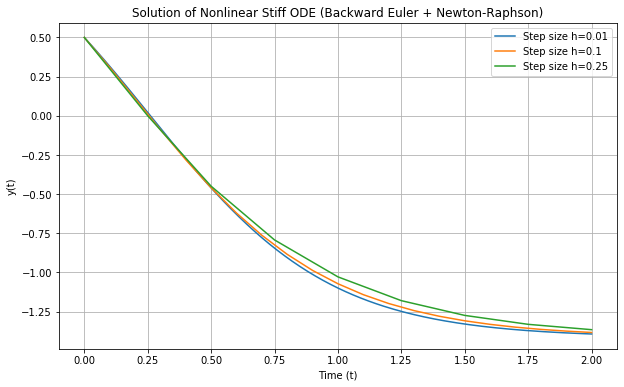

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Nonlinear ODE: dy/dt = y^2 - 2 
def f(t, y):
    return y**2 - 2

# 2. Derivative for Newton-Raphson: g'(y) = 1 - 2hy [cite: 455]
def fprime(y):
    return 2 * y

# 3. Newton-Raphson Solver for a single Backward Euler step [cite: 452, 463]
def backward_euler_step(y_prev, h, tol=1e-6, max_iter=50):
    y_next = y_prev  # Initial guess [cite: 460]
    for _ in range(max_iter):
        # g(y) calculation [cite: 454]
        g_val = y_next - y_prev - h * f(None, y_next)
        # g'(y) calculation [cite: 455]
        g_prime_val = 1 - h * fprime(y_next)
        
        if abs(g_prime_val) < 1e-12: 
            break
            
        y_new = y_next - g_val / g_prime_val
        
        # Check convergence [cite: 475]
        if abs(y_new - y_next) < tol:
            return y_new
        y_next = y_new
    return y_next

# 4. Simulation Loop [cite: 384, 385]
def run_simulation(h):
    # Parameters from Slide 45 [cite: 482-485]
    y0, t0, tf = 0.5, 0, 2
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        y_values[i] = backward_euler_step(y_values[i-1], h)
    return t_values, y_values

# 5. Generate the Plot [cite: 378]
plt.figure(figsize=(10, 6))
for step in [0.01, 0.1, 0.25]:
    t, y = run_simulation(step)
    plt.plot(t, y, label=f'Step size h={step}')

plt.title("Solution of Nonlinear Stiff ODE (Backward Euler + Newton-Raphson)")
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show() # This command renders the figure